In [14]:
from epaisseur_module import get_datacube, calcul, infos_from_csv
import matplotlib.pyplot as plt
import numpy as np
from arsf_envi_reader import envi_header
from scipy.signal import savgol_filter
import matplotlib as mpl
import pandas as pd
from optifik.minmax import thickness_from_minmax
import seaborn as sns
from sklearn.linear_model import LinearRegression

We aquire the spectrum of reflected light on a thin liquid film, thanks to a hyperspectral camera, on a spatial line and in time.
Data from the camera consist in a datacube containing the value of light intensity as a function of wavelength, time and space.
Here, we compute the thin film thickness in one point of space and time.

Computing of the thickness

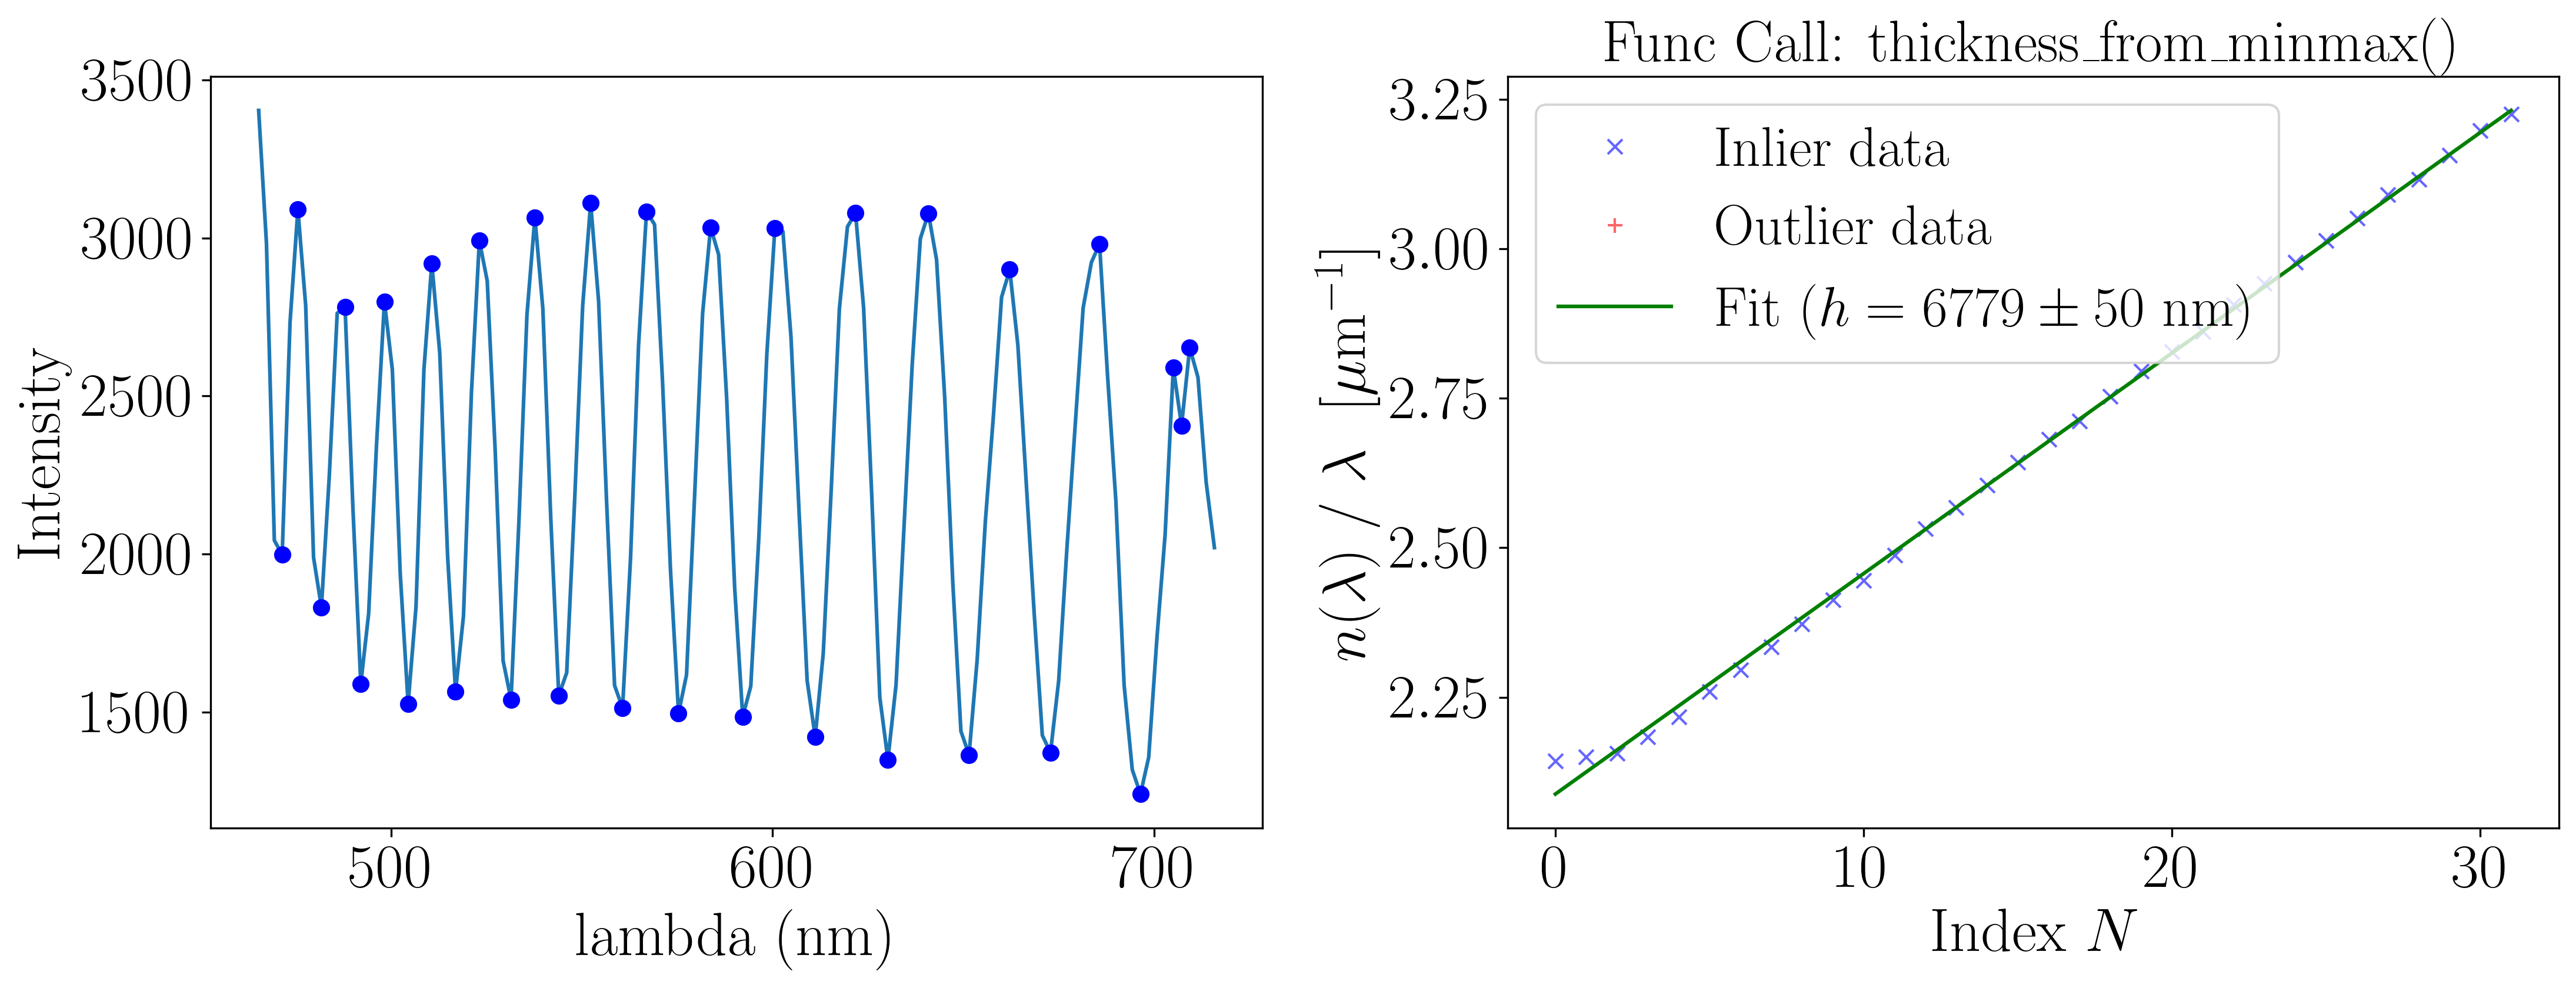

thickness = 6778.529516923534 nm


In [15]:
#file
file_bil = "26-10-23/500 rpm tige 250 lendemain matin"

#getting data from header
hdr = envi_header.read_hdr_file(file_bil+'.hdr', keep_case=False) #dictionary
n_temps = int(hdr['lines'])
n_espace = int(hdr['samples'])
file_bil = file_bil + ".bil"

#parameters
#outliers
prop_max_outliers = 1
#min and max detection
prominence = 100
distance = 1
#optical index silicone oil
n = 1.52045

#choice of point
i_space = 30 #sample
i_time  = 0 #line
#spectrum smoothing
window = None

# compute thickness in one point
[datacube,n_temps,n_espace,n_lambdas,v_time,v_space,v_lambdas] = get_datacube(file_bil)
gauche = 40 #to crop in lambdas
droite = 160
v_lambdas = v_lambdas[gauche:droite]
datacube = datacube[:,:,gauche:droite]

#spectrum smoothing
if window != None:
    datacube = savgol_filter(datacube,window,3)

thickness,prop_outliers = calcul(datacube,v_lambdas,prominence,distance,i_time,i_space,prop_max_outliers,1,n)
print('thickness =',thickness,'nm')

We use the optifik package which detects the spectrum minima and maxima (left figure).
Optifik makes a linear regression which includes the values of the wavelengths where these extrema are reached.
The film thickness value is in the coefficient of the linear regression.
We obtain that the film thickness is 7 micrometers.

By computing the thickness on the entire datacube (space, time), we can plot several thickness profiles, i.e. thickness vs spatial coordinate curves, at differents times (we do not compute the thickness here because the .bil file is very big):

proportion de spectres gardés = 0.666112511395935


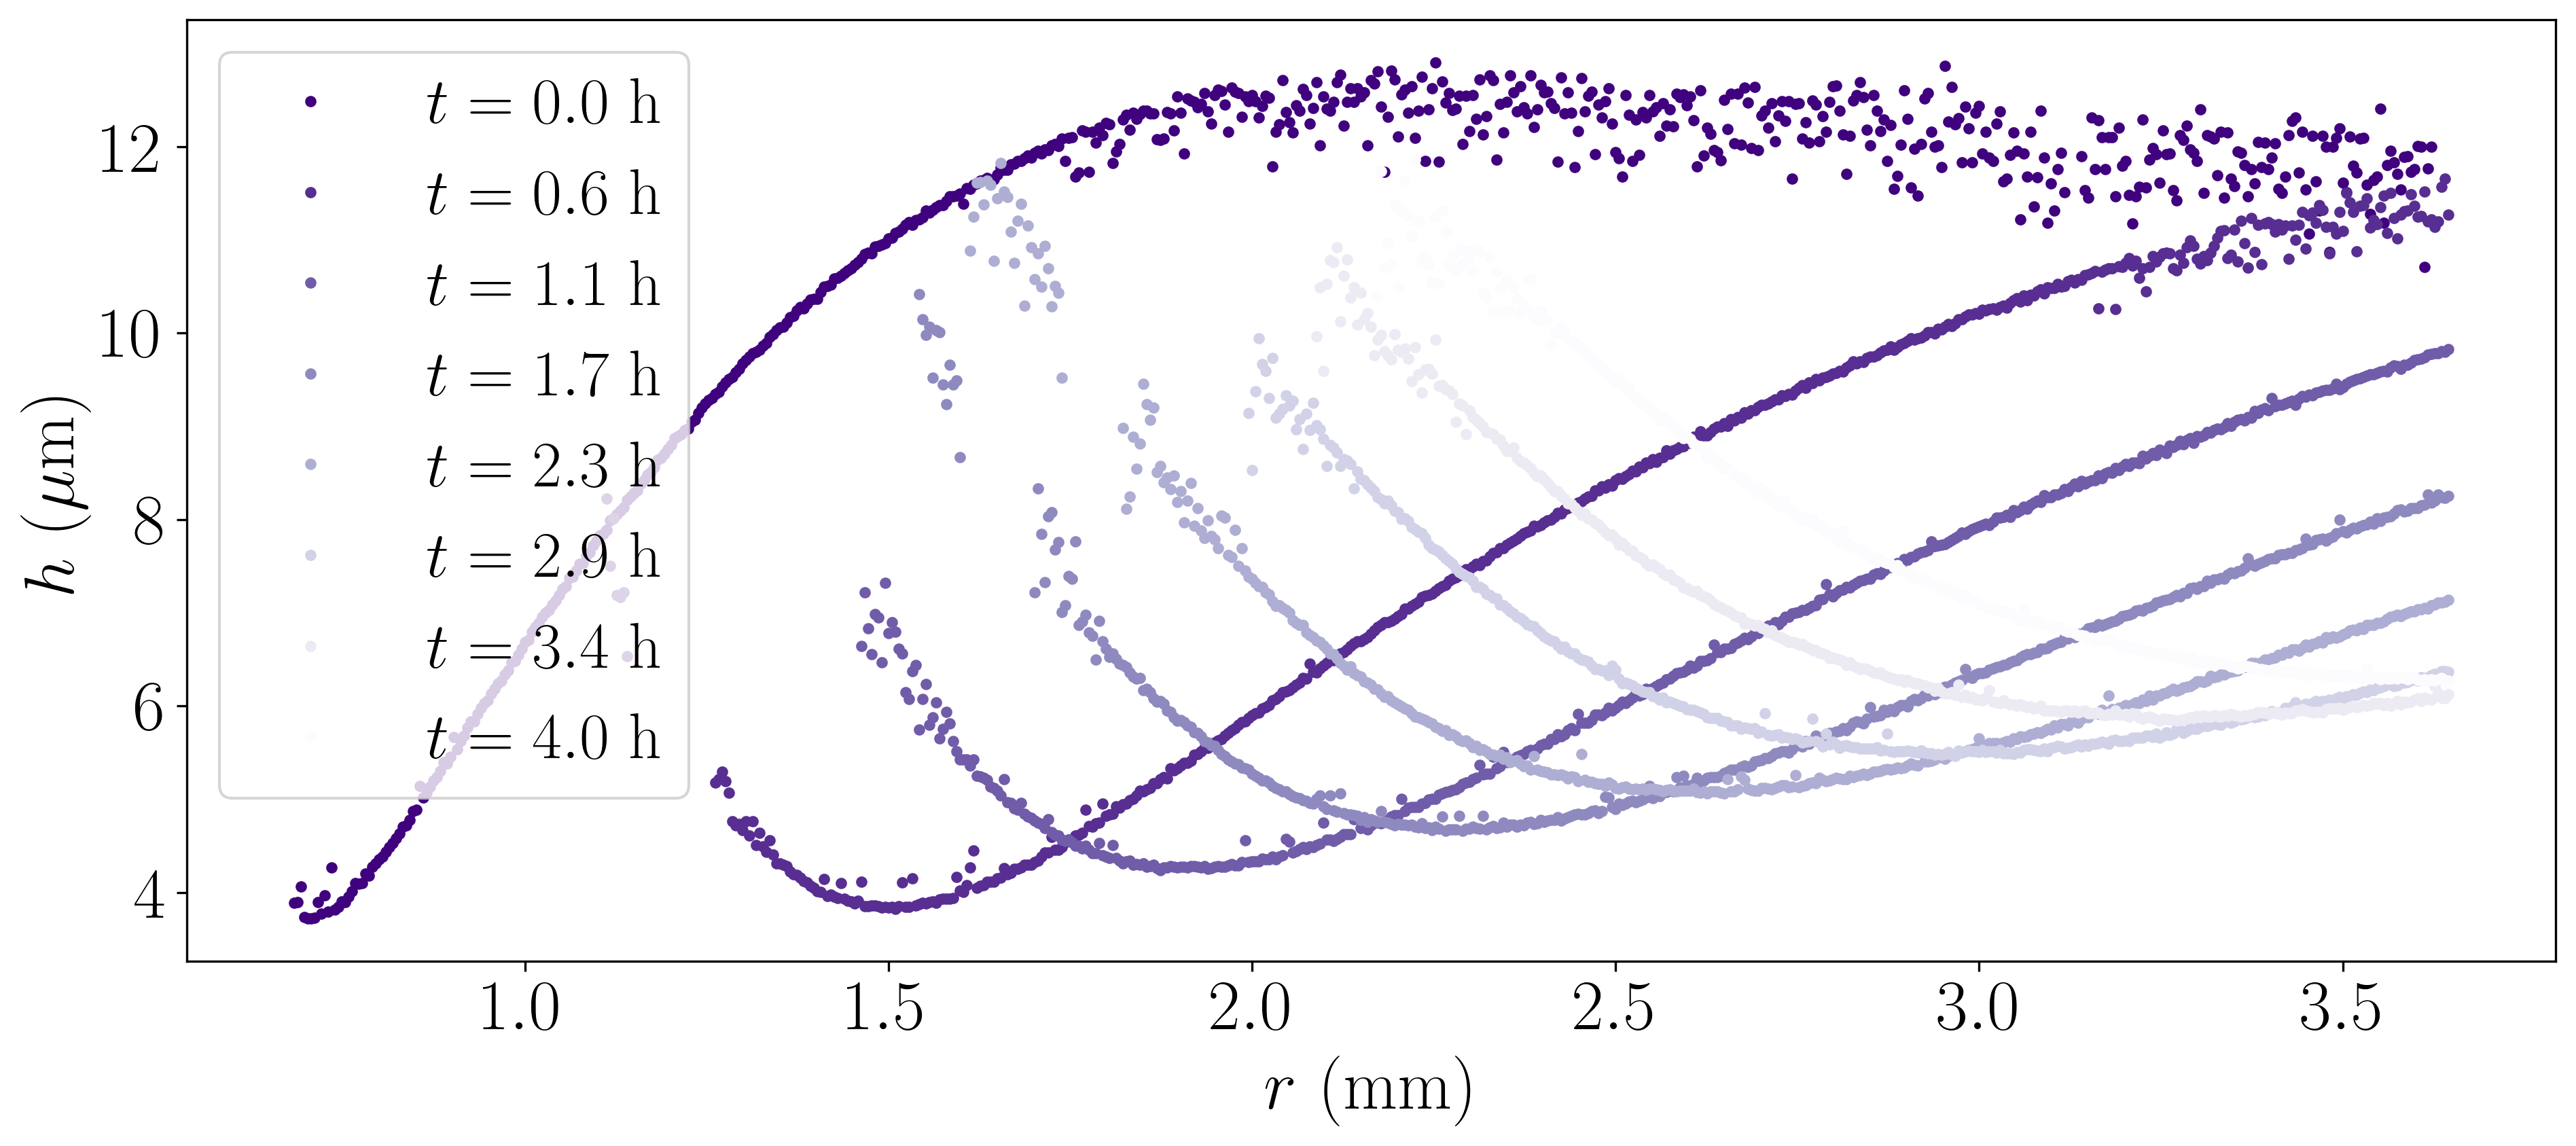

In [16]:
#file
file = '26-10-23/manip2-CropWavelengths-SpatialCrop,10,1,1,100,1,1.52045,spatemps,flip,std3-500,crop138,pisolés8-7,sauts2000,sauts1500.csv'
thickness,v_time,v_space,_ = infos_from_csv(file)

#plot
plt.figure(figsize=(15,6))
nbre_lignes = 8

#colormap
cmap = plt.get_cmap("Purples_r")
norma = mpl.colors.Normalize(vmin=np.min(v_time), vmax=np.max(v_time)+10)
sm = mpl.cm.ScalarMappable(norm=norma, cmap=cmap)
sm.set_array([])

#selection of times to plot
temps = np.linspace(1,len(v_time)-1,nbre_lignes,dtype=int)

for i in temps:
    plt.plot(v_space*1000,thickness[i,:]/1000,'.', color=cmap(norma(v_time[i])),label=r'$t = %s ~  \rm{h}$' % format(v_time[i]/3600, ".1f"))

plt.xlabel(r'$r ~ (\textrm{mm})$')
plt.ylabel(r'$h ~ (\mu \textrm{m})$')
plt.legend()

We see a groove, which moves towards the right as time goes (from dark purple to light purple).

We can track the thickness minimum of each of these profiles, that is to say the groove thickness and the position where it is reached:

In [17]:
#min value
hp = np.nanmin(thickness,1)
#location of min value
xp = np.zeros_like(v_time)
for i in range(len(v_time)):
    xp[i] = v_space[np.where(thickness[i,:]==hp[i])[0][0]] #taking the first occurence of the minimum (there can be at most two here, see next cell)

(Checking occurences of a minimum :

In [18]:
for i in range(len(v_time)):
    #print the index where a minimum occurs
    if len(np.where(thickness[i,:]==hp[i])[0]) !=1:
        print(np.where(thickness[i,:]==hp[i])[0])

[51 52]
[320 321]
[451 453]


Mimima occur not more than two times and close to each other (the next point or second to next).
We chose the first occurence.)

We can store the data in a DataFrame:

In [19]:
df = pd.DataFrame({"t (s)": v_time, "$h_p$ (nm)": hp, "$x_p$ (m)":xp})
df

,t (s),$h_p$ (nm),$x_p$ (m)
0,0.0,7997.920424,0.000701
1,100.0,3719.663814,0.000706
2,200.0,3623.014665,0.000790
3,300.0,3595.328229,0.000883
4,400.0,3583.526446,0.000944
...,...,...,...
140,14000.0,6201.147852,0.003593
141,14100.0,6211.399779,0.003584
142,14200.0,6240.523403,0.003631
143,14300.0,6255.948401,0.003645


We can plot the groove thickness and its position over time:

Text(0, 0.5, '$x_p ~ (\\mu \\textrm{mm})$')

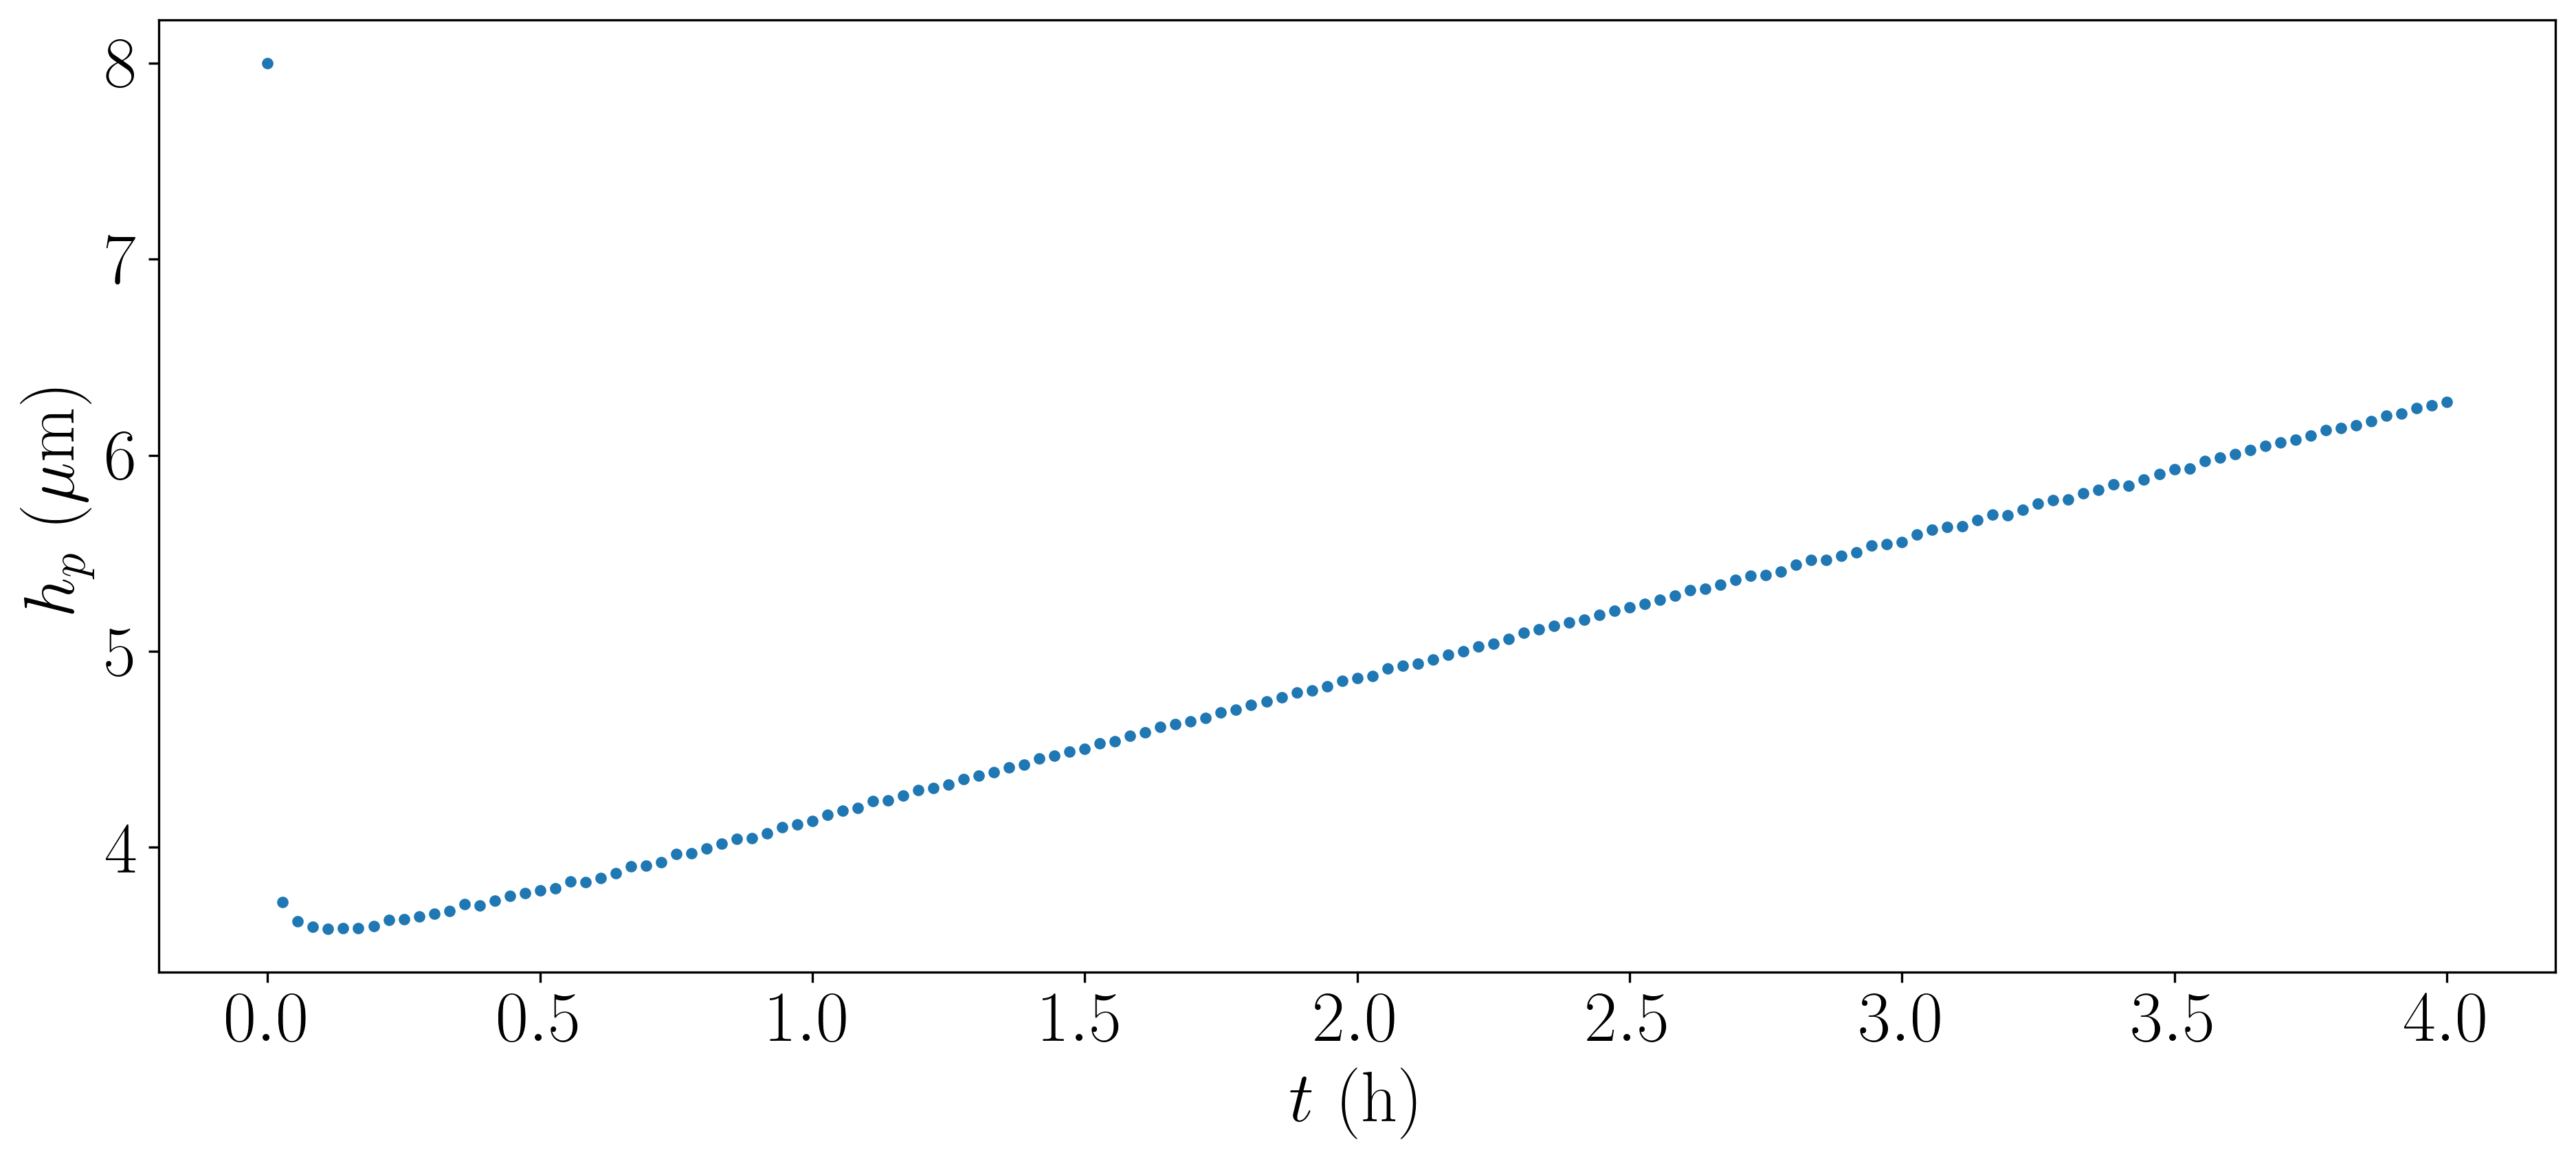

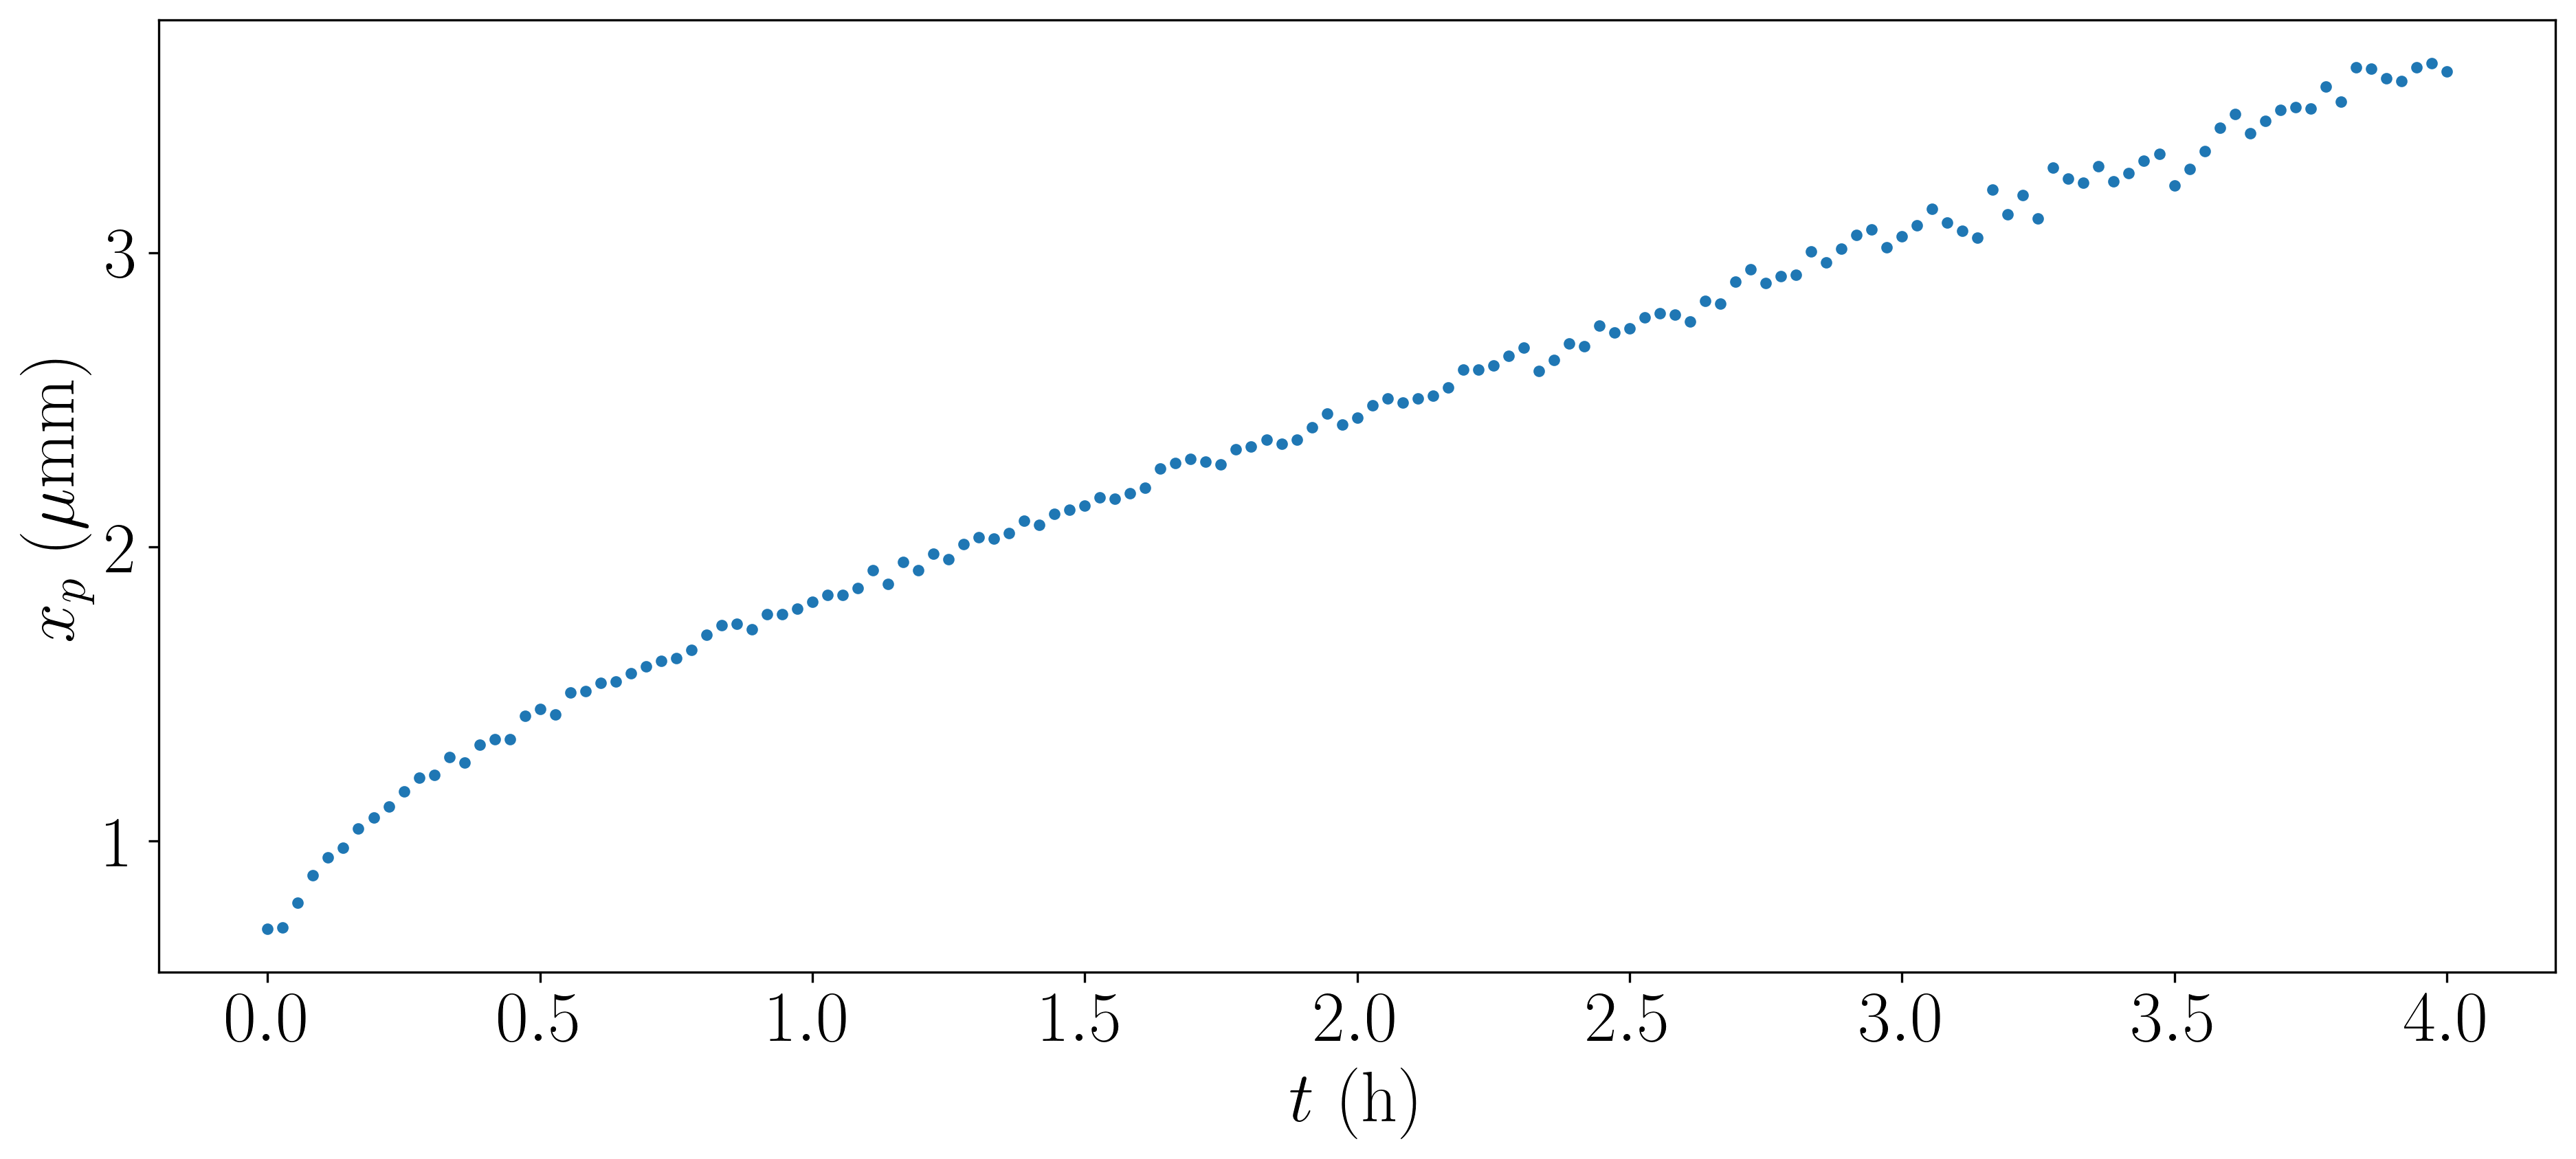

In [20]:
plt.figure(figsize=(15,6))
plt.plot(v_time/3600,hp/1000,'.')
plt.xlabel(r'$t ~ (\textrm{h})$')
plt.ylabel(r'$h_p ~ (\mu \textrm{m})$')

plt.figure(figsize=(15,6))
plt.plot(v_time/3600,xp*1000,'.')
plt.xlabel(r'$t ~ (\textrm{h})$')
plt.ylabel(r'$x_p ~ (\mu \textrm{mm})$')

The first point in the first graph is an outlier. We can have a look at the thickness profile at this instant to check what happened:

Text(0, 0.5, '$h ~ (\\mu \\textrm{m})$')

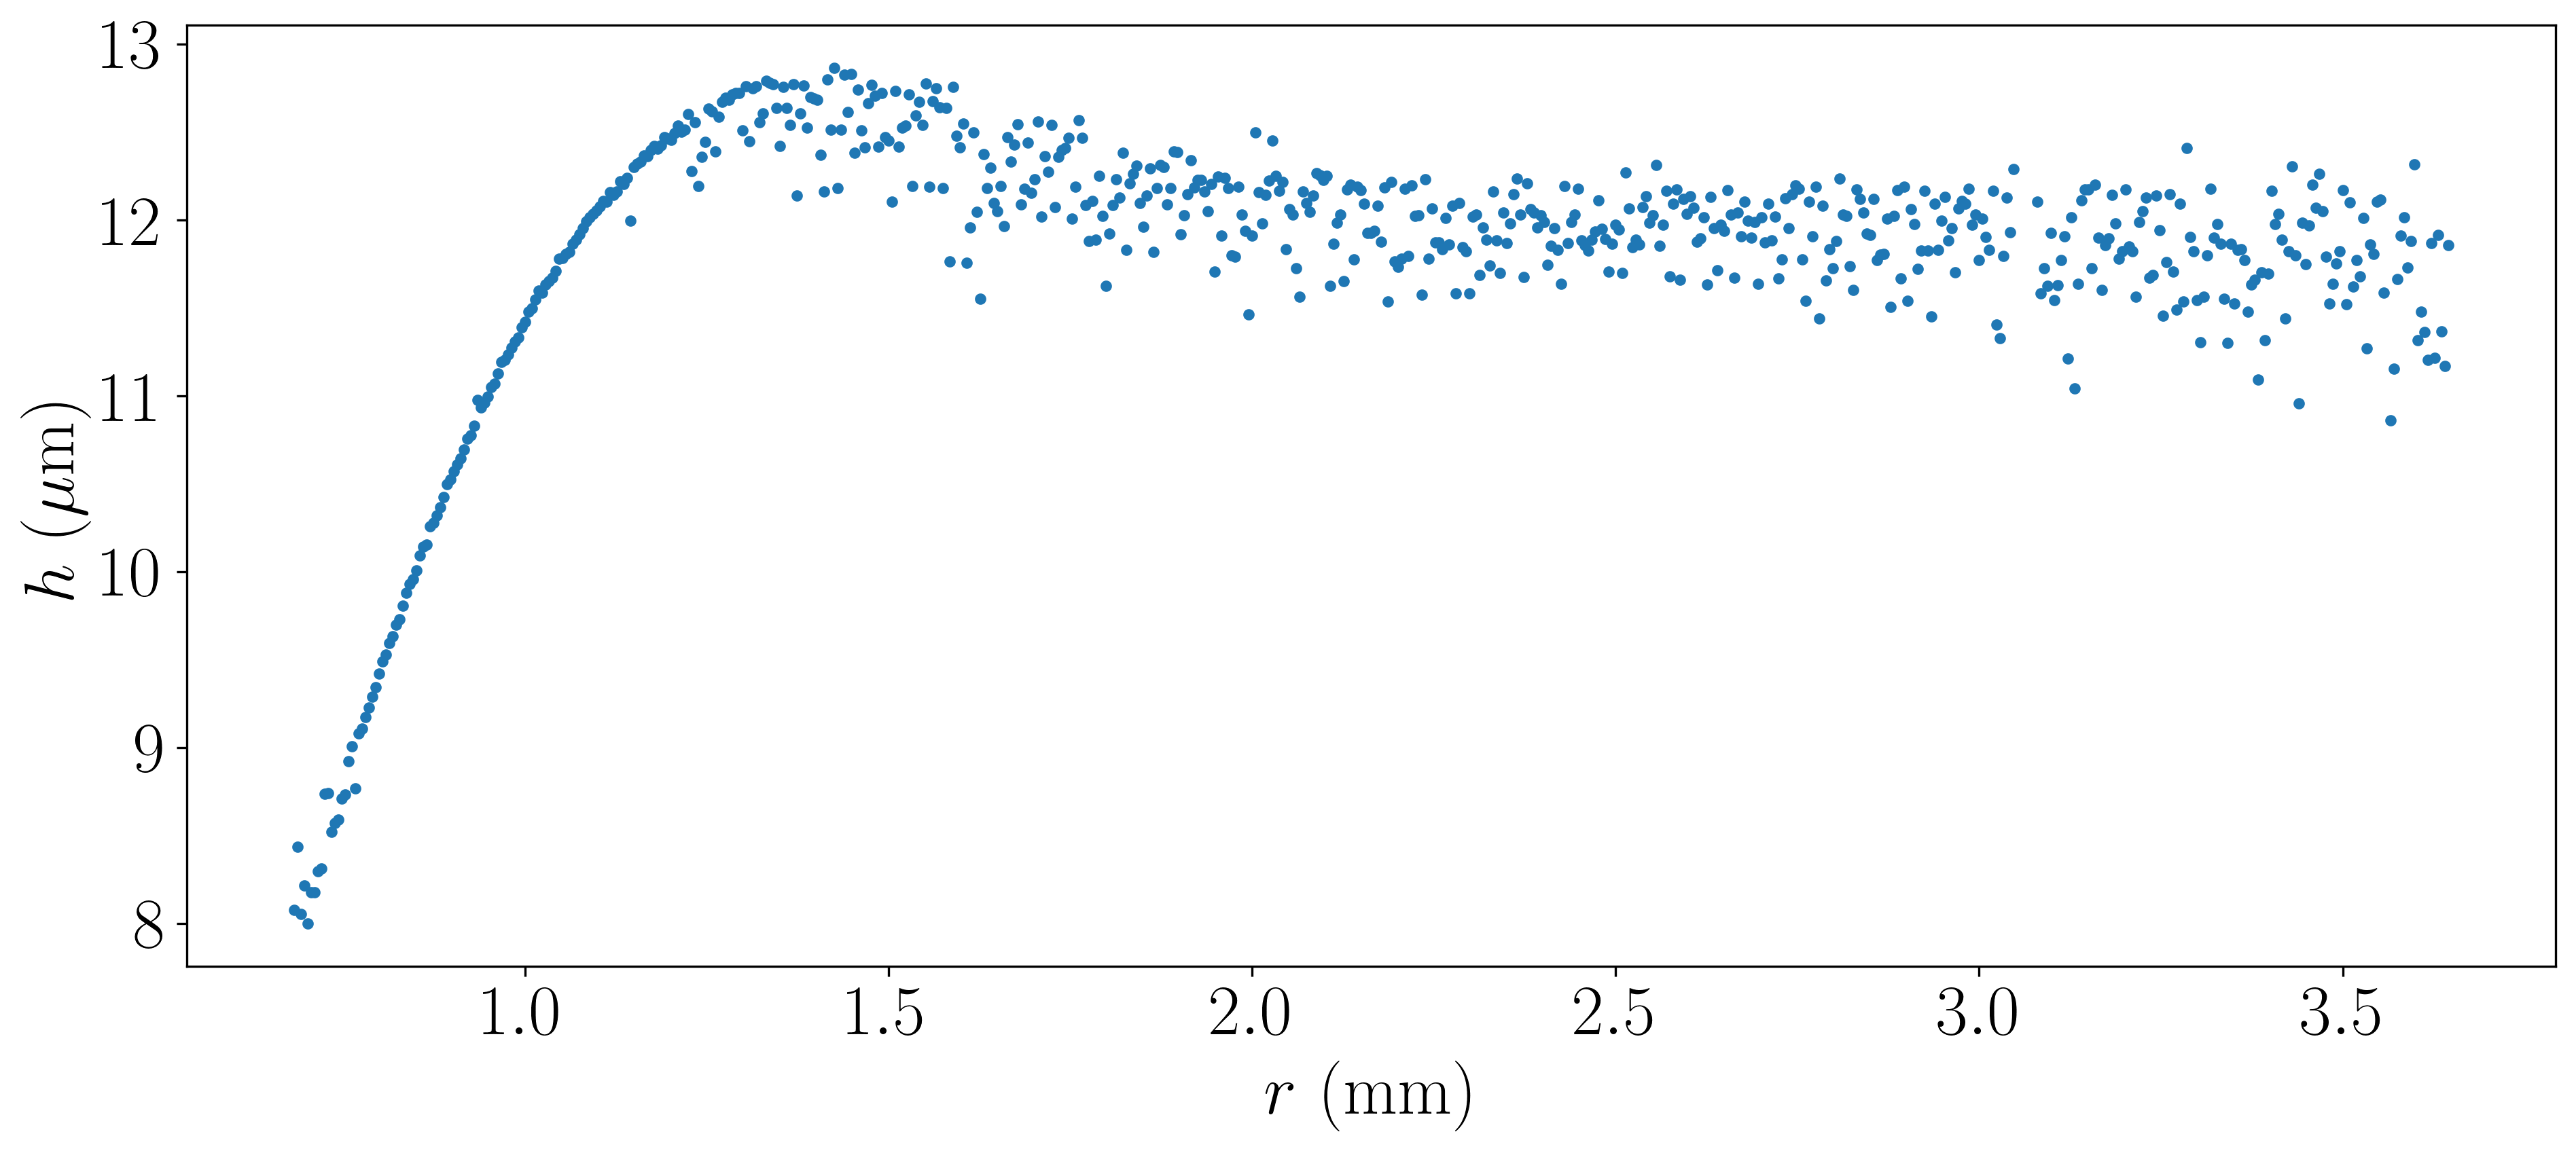

In [21]:
plt.figure(figsize=(15,6))
plt.plot(v_space*1000,thickness[0,:]/1000,'.')
plt.xlabel(r'$r ~ (\textrm{mm})$')
plt.ylabel(r'$h ~ (\mu \textrm{m})$')

We do not see the minimum here so we cannot evaluate a minimum. We discard this point.

In [22]:
df = df.drop(0)
df

,t (s),$h_p$ (nm),$x_p$ (m)
1,100.0,3719.663814,0.000706
2,200.0,3623.014665,0.000790
3,300.0,3595.328229,0.000883
4,400.0,3583.526446,0.000944
5,500.0,3586.872572,0.000977
...,...,...,...
140,14000.0,6201.147852,0.003593
141,14100.0,6211.399779,0.003584
142,14200.0,6240.523403,0.003631
143,14300.0,6255.948401,0.003645


We can see that $h_p$ is rising linearly over time. Let's check with regplot:

<Axes: xlabel='t (s)', ylabel='$h_p$ (nm)'>

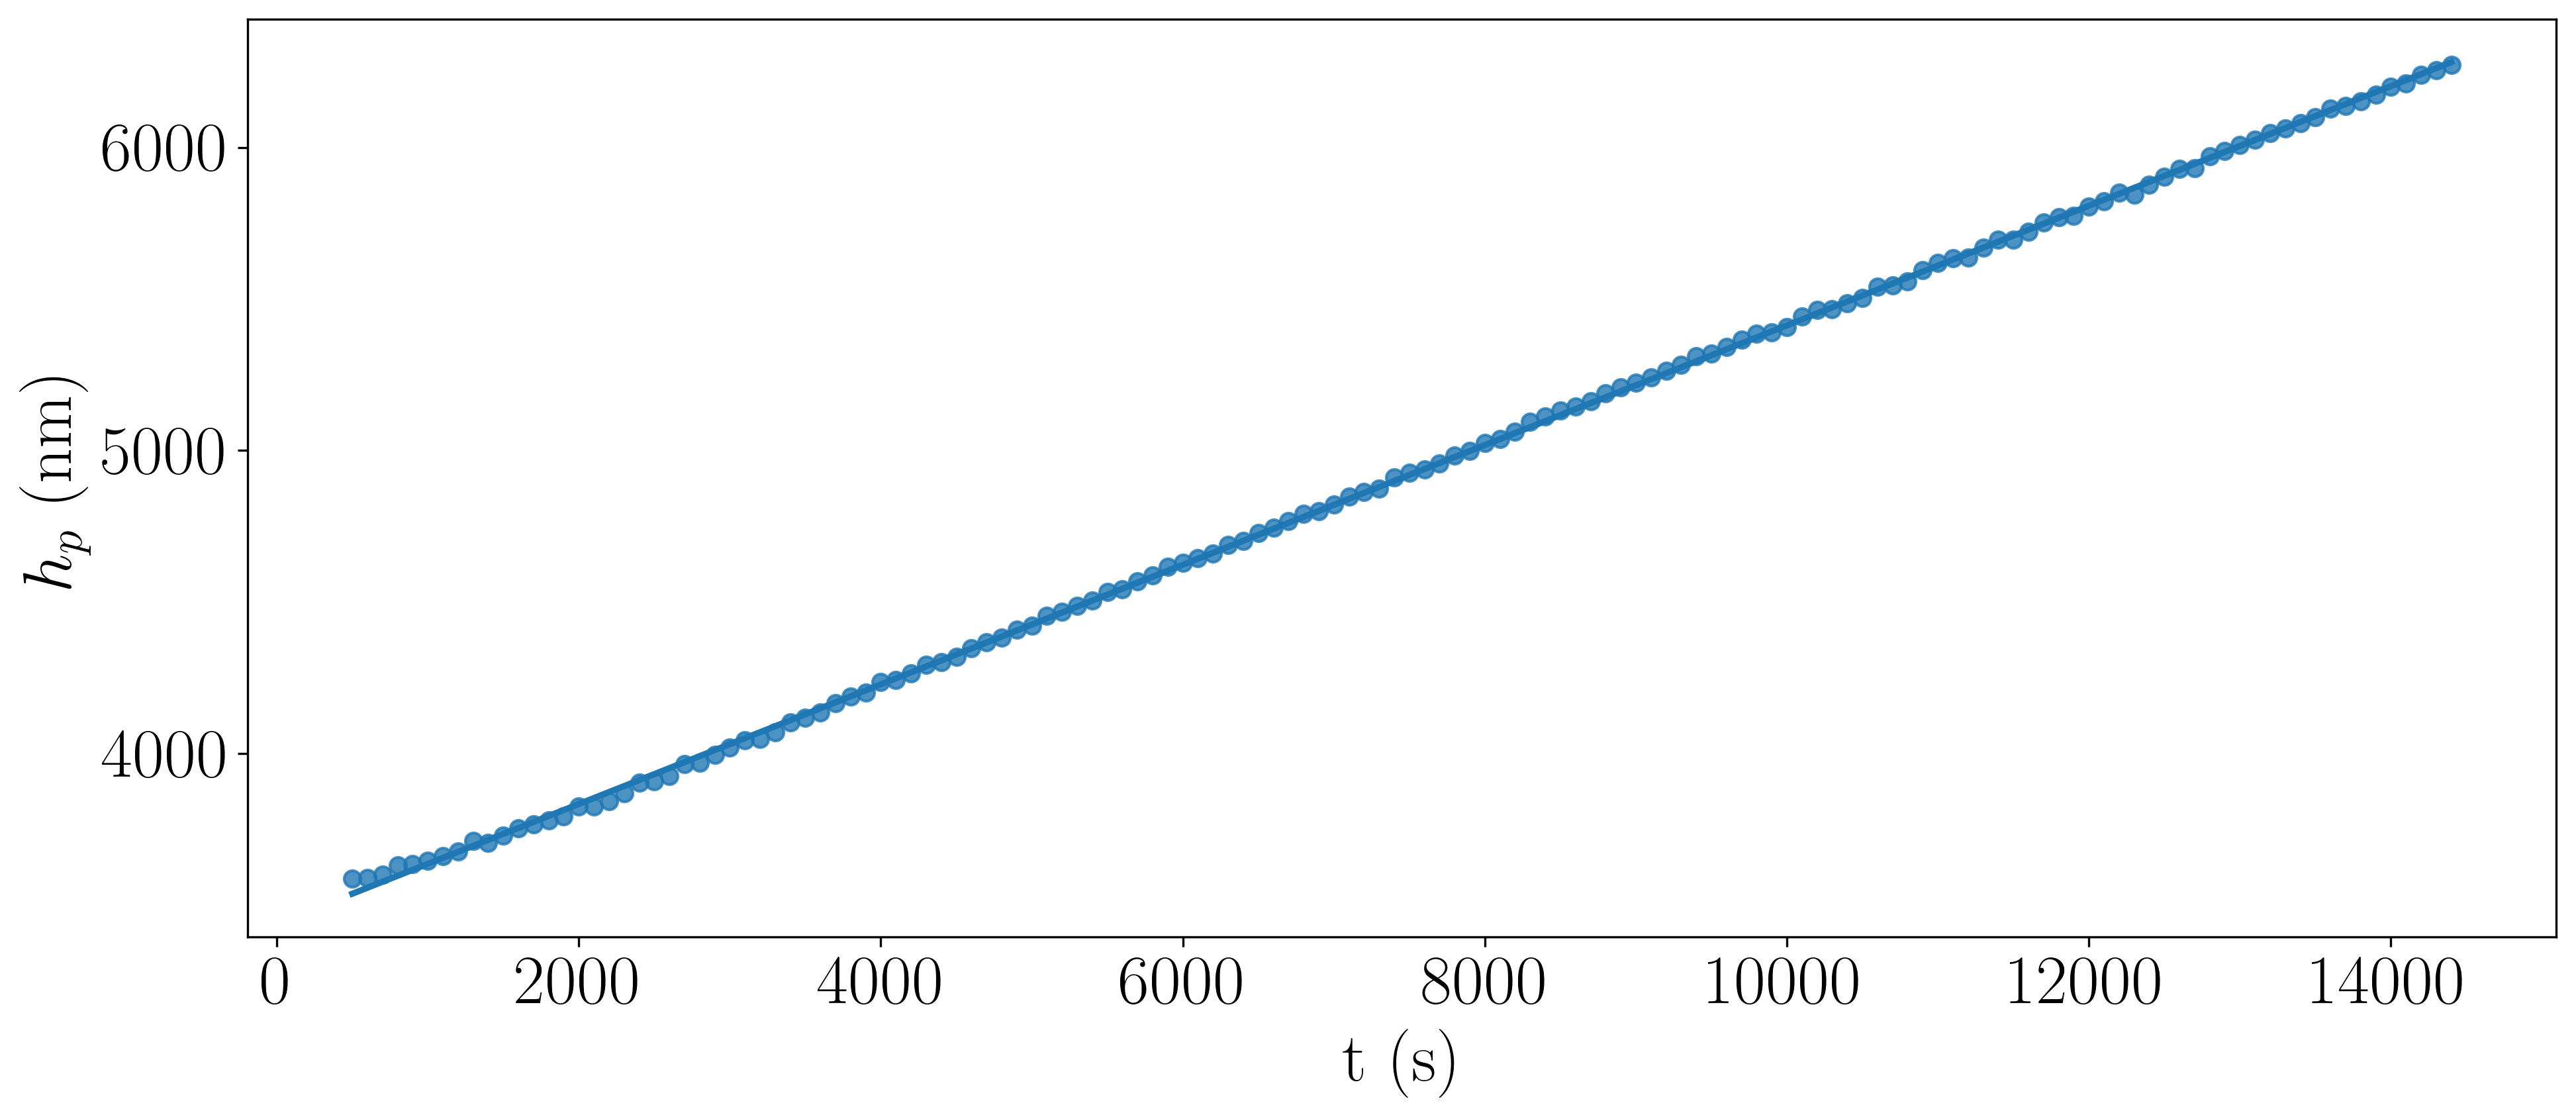

In [23]:
fig,ax = plt.subplots(figsize=(15,6))
sns.regplot(df[4:],x='t (s)',y='$h_p$ (nm)')

The evolution is indeed linear.

We do the same for the groove position as a function of time:

<Axes: xlabel='t (s)', ylabel='$x_p$ (m)'>

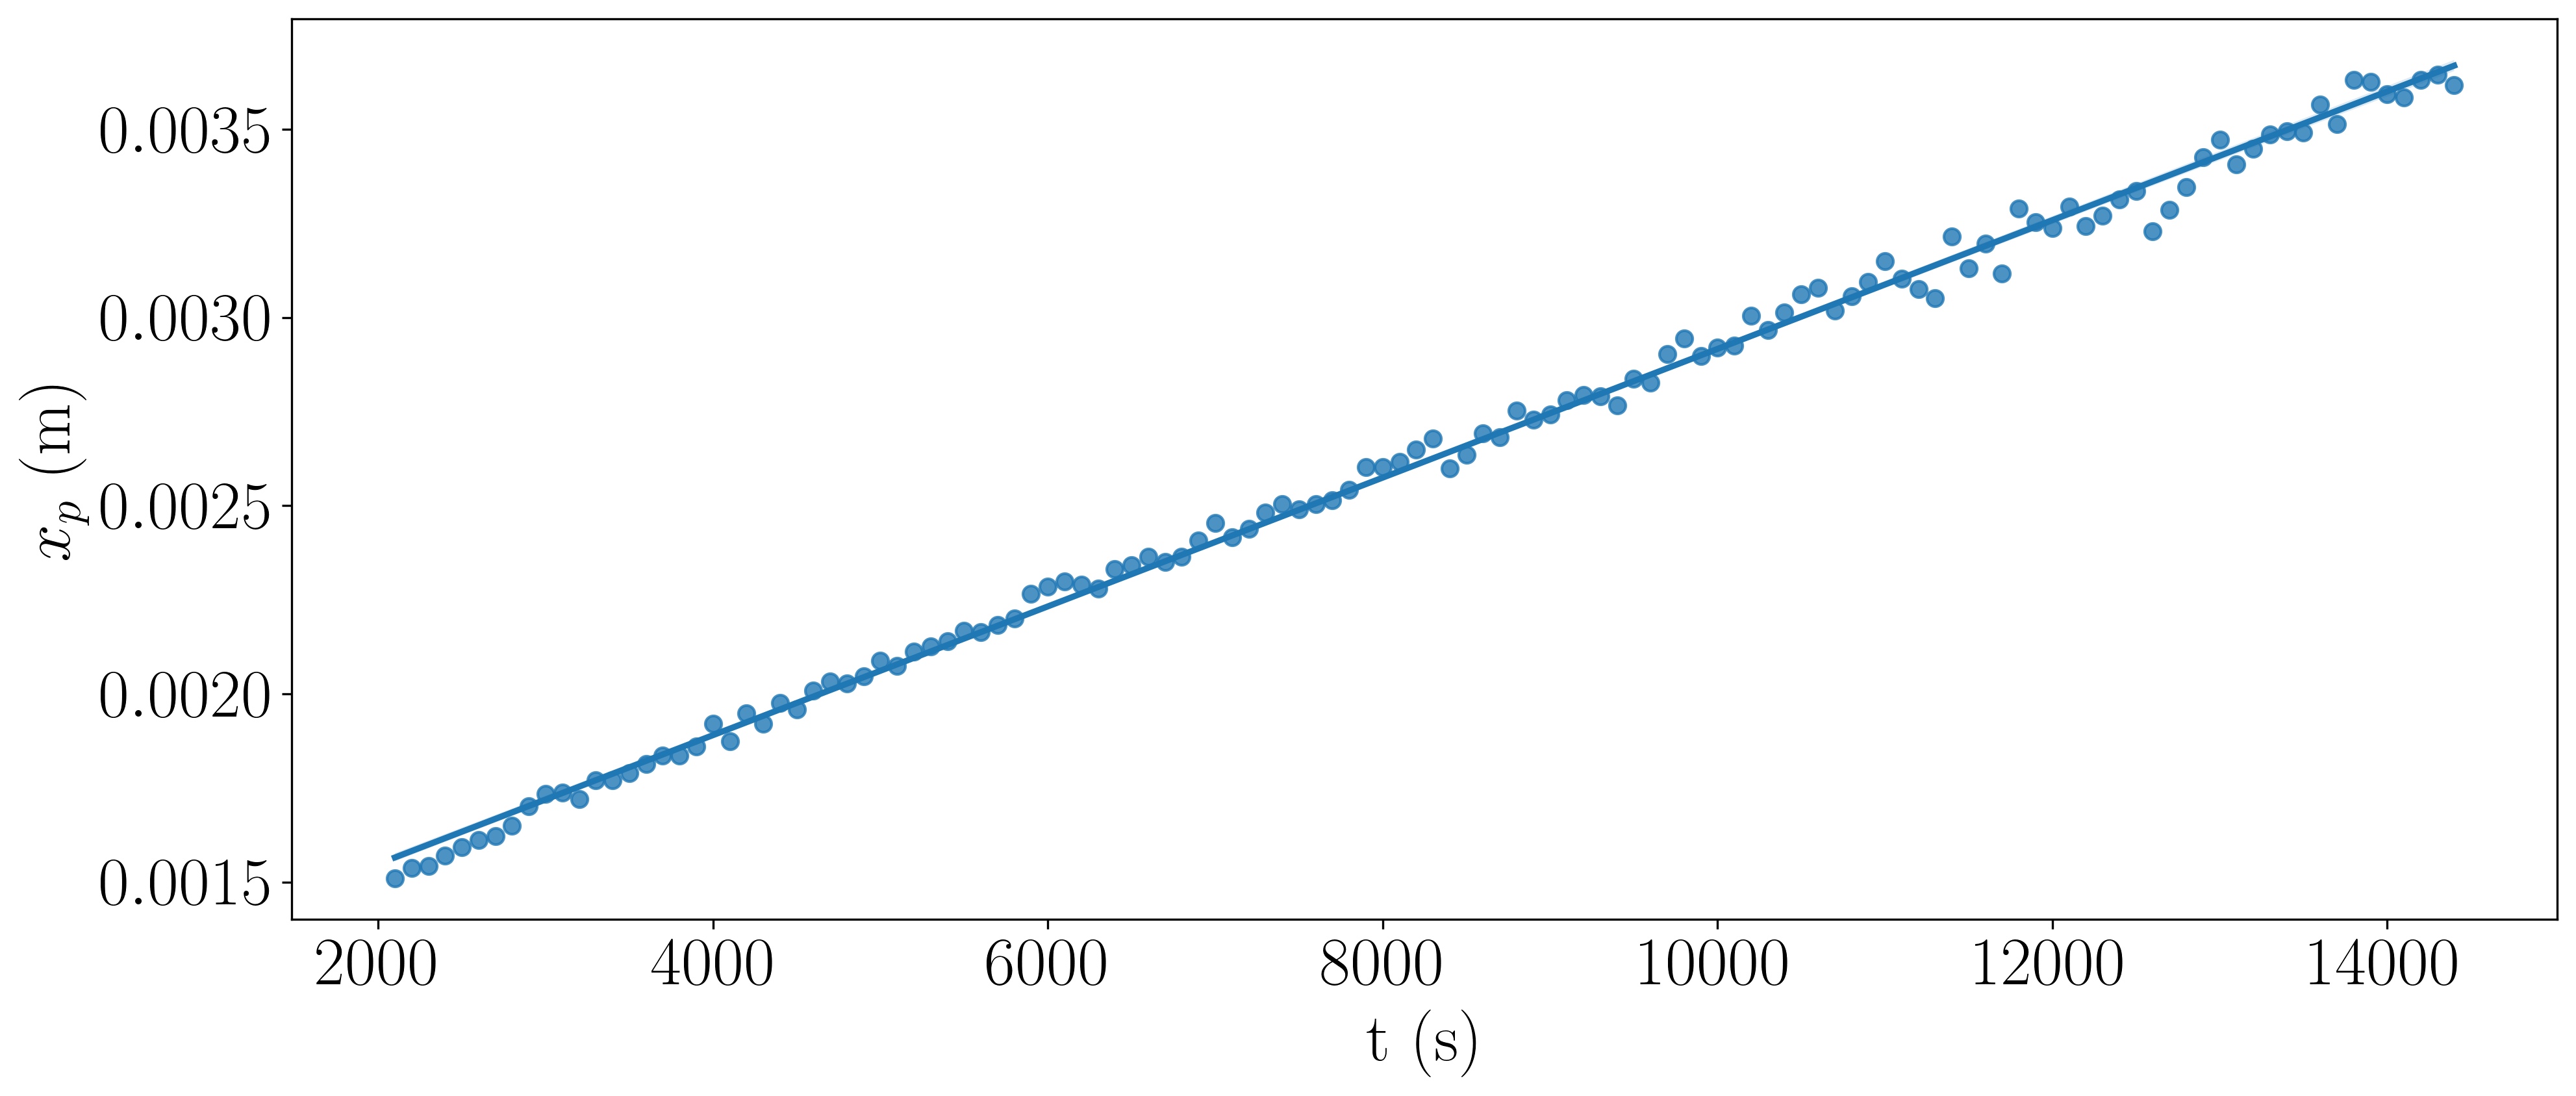

In [24]:
plt.figure(figsize=(15,6))
sns.regplot(df[20:],x='t (s)',y='$x_p$ (m)')

The evolution is indeed linear.

With sckikit learn we can obtain the coefficient of the linear regression:

In [25]:
lm = LinearRegression()
lm.fit(df[['t (s)']][20:]/3600,df['$x_p$ (m)'][20:]*1000)
lm.coef_

array([0.61566917])

We obtain a coefficient $0.6~mm/h$ which corresponds to the speed of translation of the groove.